In [133]:
#Importing the required
import datasets
from datasets import load_dataset
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from tensorflow.keras.preprocessing.text import Tokenizer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\midst\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
setwd = "D:/Sathish/AIML/Fianl Project/"

In [20]:
#Loading the Datasets
ds = load_dataset("Tobi-Bueck/customer-support-tickets")

In [21]:
pd.set_option("display.max_rows", None)   # show all rows
pd.set_option("display.max_columns", None) # show all columns
ds1 = pd.DataFrame(ds)

In [22]:
ds1.head(10)

,train
0,"{'subject': 'Wesentlicher Sicherheitsvorfall',..."
1,"{'subject': 'Account Disruption', 'body': 'Dea..."
2,{'subject': 'Query About Smart Home System Int...
3,{'subject': 'Inquiry Regarding Invoice Details...
4,{'subject': 'Question About Marketing Agency S...
5,"{'subject': 'Feature Query', 'body': 'Dear Cus..."
6,"{'subject': 'System Interruptions', 'body': 'D..."
7,{'subject': 'Connectivity Problems with Printe...
8,{'subject': 'Anfrage nach detaillierten Angabe...
9,{'subject': 'Anfrage zur Klärung der Auswirkun...


In [23]:
print(ds1['train'].iloc[0])

{'subject': 'Wesentlicher Sicherheitsvorfall', 'body': 'Sehr geehrtes Support-Team,\\n\\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\\n\\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnte die Bedrohung bislang nicht vollständig eliminiert.', 'answer': 'Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie der ergriffenen ersten Maßnahmen. Wir erk

In [24]:
data = data['train'].apply(pd.Series)
data.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [51]:
data.to_csv("Data.csv",index=False)

In [39]:
data = pd.read_csv("Raw_Data.csv")

In [40]:
data.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,wesentlicher sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,account disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,query smart home system integration features,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,inquiry regarding invoice details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,question marketing agency software compatibility,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [41]:
data.iloc[101]['body']

"Dear Customer Support Team,\\n\\nI am reaching out to seek guidance on implementing vital upgrades to our infrastructure, which are crucial for advancing the company's data processing capabilities. The objectives include improving support for sophisticated data lakes, incorporating Python-based machine learning models, and deploying automated balancing engines across various divisions. These improvements aim to enhance real-time analytical functions, ESG (Environmental, Social, Governance) reporting, and automation of investment strategies.\\n\\nAt present, our infrastructure does not support scalability."

In [42]:
data.subject.value_counts()

subject
anfrage unterstützung                                       9
dienstleistungen datenanalyse                               8
enhancing security medical data hospital systems            8
inquiry data analytics services investment optimization     8
unterstützung datenanalyse                                  8
                                                           ..
issue regarding data encryption                             1
issue project upload                                        1
effiziente optimierung investitionsportfolios               1
inquiry in-depth details financial institution offerings    1
request issue explanation                                   1
Name: count, Length: 45317, dtype: int64

In [43]:
data['language'].value_counts()

language
de    33504
en    28261
Name: count, dtype: int64

In [44]:
""" 
def translate_to_en(text, lang):
    try:
        if lang == "de":
            return GoogleTranslator(source="de", target="en").translate(text)
        return text
    except Exception as e:
        print("Translation failed:", e)
        return text  # fallback: keep original
data['subject_en'] = [translate_to_en(subj, lang) for subj, lang in zip(data['subject'], data['language'])]
data['body'] = data.apply(lambda row: translate_to_en(row['body'],row['language']),axis=1)
data['answer'] = data.apply(lambda row: translate_to_en(row['answer'],row['language']),axis=1)
"""


' \ndef translate_to_en(text, lang):\n    try:\n        if lang == "de":\n            return GoogleTranslator(source="de", target="en").translate(text)\n        return text\n    except Exception as e:\n        print("Translation failed:", e)\n        return text  # fallback: keep original\ndata[\'subject_en\'] = [translate_to_en(subj, lang) for subj, lang in zip(data[\'subject\'], data[\'language\'])]\ndata[\'body\'] = data.apply(lambda row: translate_to_en(row[\'body\'],row[\'language\']),axis=1)\ndata[\'answer\'] = data.apply(lambda row: translate_to_en(row[\'answer\'],row[\'language\']),axis=1)\n'

In [45]:
data.drop_duplicates(inplace=True)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  object 
 1   body      61763 non-null  object 
 2   answer    48576 non-null  object 
 3   type      48587 non-null  object 
 4   queue     61765 non-null  object 
 5   priority  61765 non-null  object 
 6   language  61765 non-null  object 
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  object 
 9   tag_2     48528 non-null  object 
 10  tag_3     48356 non-null  object 
 11  tag_4     43990 non-null  object 
 12  tag_5     27636 non-null  object 
 13  tag_6     13225 non-null  object 
 14  tag_7     5968 non-null   object 
 15  tag_8     2472 non-null   object 
dtypes: float64(1), object(15)
memory usage: 7.5+ MB


In [47]:
for i in data.columns:
    print(i,":", (100*data[i].isnull().sum()/data.shape[0]))

subject : 8.579292479559621
body : 0.00323807981866753
answer : 21.35351736420303
type : 21.335707925200357
queue : 0.0
priority : 0.0
language : 0.0
version : 53.71650611187566
tag_1 : 21.335707925200357
tag_2 : 21.431231279851048
tag_3 : 21.709706144256455
tag_4 : 28.778434388407675
tag_5 : 55.25621306565207
tag_6 : 78.58819719906096
tag_7 : 90.3375698210961
tag_8 : 95.99773334412693


In [ ]:
#Data Preprocessing
def clean_text(text, lang):
    if not isinstance(text,str):
        return ""
    if lang == 'en':
        text = text.lower()
        text = re.sub("'","",text)
        text = re.sub(r'\s+',' ',text)
        text = re.sub(r'\n+',' ',text)
        tokens = word_tokenize(text,language='english')
        token = [i for i in tokens if i not in stopwords.words('english') and i not in string.punctuation]
        return " ".join(token)
    else:
        text = text.lower()
        text = re.sub("'","",text)
        text = re.sub(r'\s+',' ',text)
        text = re.sub(r'\n+',' ',text)
        tokens = word_tokenize(text,language='german')
        token = [i for i in tokens if i not in stopwords.words('german') and i not in string.punctuation] 
        return " ".join(token)
data['subject'] = data.apply(lambda row: clean_text(row['subject'],row['language']),axis=1)
data['body'] = data.apply(lambda row: clean_text(row['body'],row['language']),axis=1)
data['answer'] = data.apply(lambda row: clean_text(row['answer'],row['language']),axis=1)

In [50]:
data.iloc[1]['subject']

'account disruption'

In [51]:
data.to_csv("Clean_data.csv",index=False)

In [95]:
#Loading the cleaned datset
data = pd.read_csv("Clean_data.csv")

In [96]:
keywords = ["refund", "login issue", "payment failed"]
sia = SentimentIntensityAnalyzer()
urgency_words = ["urgent","asap","immediately"]
def keyword_features(text):
    if not isinstance(text,str):
        return ""
    return {f"has_{kw}": (kw in text) for kw in keywords}
def urgency_features(text):
    if not isinstance(text,str):
        return ""
    return {f"has_{ug}":(ug in text) for ug in urgency_words}

In [97]:
def sentiment_score(text):
    if not isinstance(text,str):
        return ""
    scores =sia.polarity_scores(text)
    return {
        "pos":scores['pos'],
        "neg":scores['neg'],
        'neu':scores['neu'],
        'com':scores['compound']
    }

In [98]:
def extract_features(text):
    features = {}
    features.update(keyword_features(text))
    features.update(urgency_features(text))
    features.update(sentiment_score(text))
    return features

In [99]:
data_en = data[data['language'] == 'en']

In [103]:
data_en.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28261 entries, 1 to 61762
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   24622 non-null  object 
 1   body      28260 non-null  object 
 2   answer    28255 non-null  object 
 3   type      28261 non-null  object 
 4   queue     28261 non-null  object 
 5   priority  28261 non-null  object 
 6   language  28261 non-null  object 
 7   version   16338 non-null  float64
 8   tag_1     28261 non-null  object 
 9   tag_2     28245 non-null  object 
 10  tag_3     28148 non-null  object 
 11  tag_4     25677 non-null  object 
 12  tag_5     16301 non-null  object 
 13  tag_6     7908 non-null   object 
 14  tag_7     3699 non-null   object 
 15  tag_8     1608 non-null   object 
dtypes: float64(1), object(15)
memory usage: 3.7+ MB


In [105]:
data_en = data_en[~(data_en['body'].isnull())]

In [106]:
features = data_en['body'].apply(extract_features)
features_df = features.apply(pd.Series)

In [107]:
features.shape

(28260,)

In [108]:
data1 = pd.concat([data_en,features_df],axis = 1)

In [109]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28260 entries, 1 to 61762
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subject             24621 non-null  object 
 1   body                28260 non-null  object 
 2   answer              28254 non-null  object 
 3   type                28260 non-null  object 
 4   queue               28260 non-null  object 
 5   priority            28260 non-null  object 
 6   language            28260 non-null  object 
 7   version             16338 non-null  float64
 8   tag_1               28260 non-null  object 
 9   tag_2               28244 non-null  object 
 10  tag_3               28147 non-null  object 
 11  tag_4               25676 non-null  object 
 12  tag_5               16300 non-null  object 
 13  tag_6               7907 non-null   object 
 14  tag_7               3699 non-null   object 
 15  tag_8               1608 non-null   object 
 16  has_refun

In [110]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28260 entries, 1 to 61762
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subject             24621 non-null  object 
 1   body                28260 non-null  object 
 2   answer              28254 non-null  object 
 3   type                28260 non-null  object 
 4   queue               28260 non-null  object 
 5   priority            28260 non-null  object 
 6   language            28260 non-null  object 
 7   version             16338 non-null  float64
 8   tag_1               28260 non-null  object 
 9   tag_2               28244 non-null  object 
 10  tag_3               28147 non-null  object 
 11  tag_4               25676 non-null  object 
 12  tag_5               16300 non-null  object 
 13  tag_6               7907 non-null   object 
 14  tag_7               3699 non-null   object 
 15  tag_8               1608 non-null   object 
 16  has_refun

In [111]:
#data1[['has_refund','has_login issue','has_payment failed','has_urgent','has_asap','has_immediately']] = data1[['has_refund','has_login issue','has_payment failed','has_urgent','has_asap','has_immediately']].astype(bool)

In [112]:
X_features = data1[['has_refund','has_login issue','has_payment failed','has_urgent','has_asap','has_immediately','pos','neg','neu','com']]
X_features = X_features.astype(float)

In [113]:
data1[['body','has_refund','has_login issue','has_payment failed','has_urgent','has_asap','has_immediately','pos','neg','neu','com']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 28260 entries, 1 to 61762
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   body                28260 non-null  object 
 1   has_refund          28260 non-null  bool   
 2   has_login issue     28260 non-null  bool   
 3   has_payment failed  28260 non-null  bool   
 4   has_urgent          28260 non-null  bool   
 5   has_asap            28260 non-null  bool   
 6   has_immediately     28260 non-null  bool   
 7   pos                 28260 non-null  float64
 8   neg                 28260 non-null  float64
 9   neu                 28260 non-null  float64
 10  com                 28260 non-null  float64
dtypes: bool(6), float64(4), object(1)
memory usage: 1.5+ MB


In [114]:
X_features.shape

(28260, 10)

In [115]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28260 entries, 1 to 61762
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subject             24621 non-null  object 
 1   body                28260 non-null  object 
 2   answer              28254 non-null  object 
 3   type                28260 non-null  object 
 4   queue               28260 non-null  object 
 5   priority            28260 non-null  object 
 6   language            28260 non-null  object 
 7   version             16338 non-null  float64
 8   tag_1               28260 non-null  object 
 9   tag_2               28244 non-null  object 
 10  tag_3               28147 non-null  object 
 11  tag_4               25676 non-null  object 
 12  tag_5               16300 non-null  object 
 13  tag_6               7907 non-null   object 
 14  tag_7               3699 non-null   object 
 15  tag_8               1608 non-null   object 
 16  has_refun

In [116]:
tf_body = TfidfVectorizer()
body = tf_body.fit_transform(data1['body'])

In [117]:
X_features.shape

(28260, 10)

In [118]:
body.shape

(28260, 5950)

In [ ]:
from scipy.sparse import hstack
X = hstack([body,X_features])
le = LabelEncoder()
y = le.fit_transform(data1['queue'])

In [120]:
X_train, X_temp, y_train,y_temp = train_test_split(X,y,test_size=0.2,random_state=42)

In [121]:
X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

In [122]:
model = LogisticRegression()

In [123]:
model.fit(X_train,y_train)

c:\Users\midst\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [124]:
y_val_prec = model.predict(X_val)

In [125]:
from sklearn.metrics import precision_score,recall_score,accuracy_score,confusion_matrix,f1_score

In [126]:
print(accuracy_score(y_val,y_val_prec))
print("Precision (macro):", precision_score(y_val,y_val_prec, average='macro'))
print("Recall (macro):", recall_score(y_val,y_val_prec, average='macro'))
print("F1 (macro):", f1_score(y_val,y_val_prec, average='macro'))

0.48018400566171265
Precision (macro): 0.6740000374555389
Recall (macro): 0.358025921181646
F1 (macro): 0.40657722616512126


In [127]:
from sklearn.naive_bayes import MultinomialNB

In [128]:
nb = MultinomialNB()
nb.fit(X_train,y_train)

ValueError: Negative values in data passed to MultinomialNB (input X).

In [129]:
from sklearn.naive_bayes import GaussianNB
gb = GaussianNB()
gb.fit(X_train.toarray(),y_train)
y_val_pred = gb.predict(X_val.toarray())

In [130]:
print(accuracy_score(y_val,y_val_pred))
print("Precision (macro):", precision_score(y_val,y_val_pred, average='macro'))

0.2883934890304317
Precision (macro): 0.31664491439997466


In [131]:
svm = LinearSVC()
svm.fit(X_train,y_train)
y_val_pred = svm.predict(X_val)

In [132]:
print(accuracy_score(y_val,y_val_pred))
print("Precision (macro):", precision_score(y_val,y_val_pred, average='macro'))

0.5467091295116773
Precision (macro): 0.6628280489029329


In [134]:
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(data1['body'])
body_en = word_tokenizer.texts_to_sequences(data1['body'])

<Axes: >

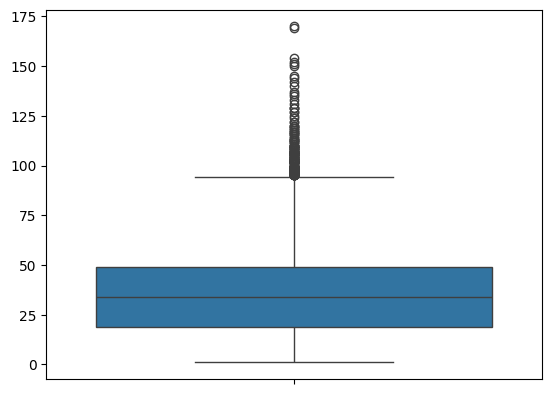

In [135]:
lengths = [len(sent) for sent in body_en]
sns.boxplot(lengths)

In [136]:
#Padding is set to 100
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = 100
body1 = pad_sequences(body_en,maxlen = 100,padding = "pre",truncating ="post")

In [139]:
import warnings
warnings.filterwarnings("ignore")

In [140]:
from tensorflow.keras.layers import Embedding
vocab_size = len(word_tokenizer.word_index)+1
embedding_dim = 100
max_len = 100
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len
)

In [137]:
from tensorflow.keras.utils import to_categorical
y_onehot = to_categorical(y)

In [143]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(embedding_layer)
model.add(LSTM(128))  # Many-to-One: only final hidden state is used
model.add(Dense(len(le.classes_), activation='softmax'))

In [145]:
X_train, X_temp, y_train, y_temp = train_test_split(body1, y_onehot, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [146]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data = (X_val,y_val))

Epoch 1/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.4420 - loss: 1.5551 - val_accuracy: 0.4646 - val_loss: 1.5017
Epoch 2/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.5102 - loss: 1.3805 - val_accuracy: 0.4922 - val_loss: 1.4309
Epoch 3/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.5761 - loss: 1.2212 - val_accuracy: 0.4996 - val_loss: 1.3973
Epoch 4/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.6363 - loss: 1.0720 - val_accuracy: 0.5499 - val_loss: 1.3420
Epoch 5/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 57s 80ms/step - accuracy: 0.6917 - loss: 0.9266 - val_accuracy: 0.5761 - val_loss: 1.3150
Epoch 6/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 71s 100ms/step - accuracy: 0.7354 - loss: 0.8001 - val_accuracy: 0.5927 - val_loss: 1.3205
Epoch 7/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 74s 104ms/step - accuracy: 0.7758 - loss: 0.6923 - val_accuracy: 0.6083 - val_loss: 1.3597
Epoch 8/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.8108 - loss: 0.5891 

In [147]:
preds = model.predict(body1)
predicted_labels = le.inverse_transform(preds.argmax(axis=1))

884/884 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step


In [149]:
y_test_labels = le.inverse_transform(y_test.argmax(axis=1))
y_pred_labels = predicted_labels[:len(y_test_labels)]
from sklearn.metrics import classification_report
print("Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print(classification_report(y_test_labels, y_pred_labels))

Accuracy: 0.18719037508846426
                                 precision    recall  f1-score   support

           Billing and Payments       0.12      0.10      0.11       298
               Customer Service       0.16      0.14      0.15       407
                General Inquiry       0.00      0.00      0.00        29
                Human Resources       0.00      0.00      0.00        55
                     IT Support       0.13      0.13      0.13       336
                Product Support       0.21      0.23      0.22       536
          Returns and Exchanges       0.05      0.04      0.05       139
            Sales and Pre-Sales       0.01      0.01      0.01        79
Service Outages and Maintenance       0.04      0.05      0.04       104
              Technical Support       0.31      0.31      0.31       843

                       accuracy                           0.19      2826
                      macro avg       0.10      0.10      0.10      2826
                   

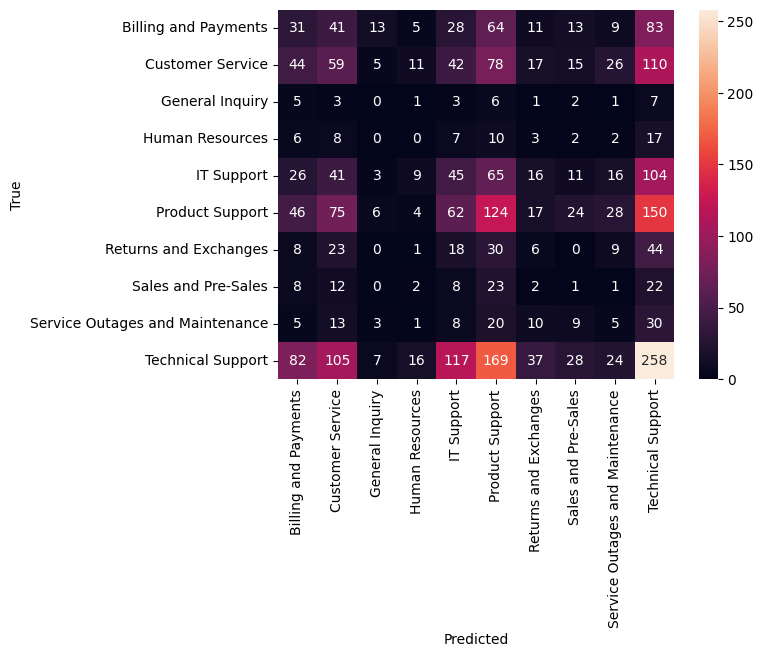

In [150]:
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [151]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

In [157]:
X_train, X_temp, y_train, y_temp = train_test_split(data1['body'], data1['queue'], test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [159]:
train_df = pd.DataFrame({'text':X_train,'label':y_train})
val_df = pd.DataFrame({'text':X_val,'label':y_val})
test_df = pd.DataFrame({'text':X_test,'label':y_test})

In [160]:
#Converting the dataset as a Huggigngface dataset object
from datasets import Dataset, DatasetDict
dataset = DatasetDict({
    "train":Dataset.from_pandas(train_df),
    "val":Dataset.from_pandas(val_df),
    "test":  Dataset.from_pandas(test_df)
})

In [163]:
model_checkpoint = "bert-base-cased"
# Define the batch size for the training
batch_size = 32

In [162]:
# Load the tokenizer for the specified model checkpoint using Hugging Face AutoTokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [165]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=75
    )

# Apply to all splits at once
tokenized_datasets = dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/22608 [00:00<?, ? examples/s]

Map:   0%|          | 0/2826 [00:00<?, ? examples/s]

Map:   0%|          | 0/2826 [00:00<?, ? examples/s]

In [166]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 22608
    })
    val: Dataset({
        features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2826
    })
    test: Dataset({
        features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2826
    })
})

In [173]:
pre_tokenizer_columns = set(dataset["train"].features)
tokenized_datasets['train'].features
tokenizer_columns = list(set(tokenized_datasets["train"].features) - pre_tokenizer_columns)
print("Columns added by tokenizer:", tokenizer_columns)


Columns added by tokenizer: ['attention_mask', 'input_ids', 'token_type_ids']


{'__index_level_0__', 'label', 'text'}